# 4 — Portfolio Construction

**Mandatory Task B**: Generate portfolios for different investor profiles.

- **Conservative**: Minimize variance, cap individual stock weight at 10%
- **Balanced**: Maximize Sharpe ratio, cap at 20% per stock
- **Aggressive**: Maximize expected return, cap at 30% per stock
- Efficient Frontier visualization
- Compare against equal-weight (1/N) baseline

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from scipy.optimize import minimize

from src.preprocess import get_aligned_returns, load_metadata
from src.preprocess import RISK_FREE_RATE, TRADING_DAYS

%matplotlib inline

## 4.1 Load Returns Data

In [2]:
returns = get_aligned_returns()
meta = load_metadata()

print(f'Returns shape: {returns.shape}')
print(f'Date range: {returns.index.min()} → {returns.index.max()}')
print(f'Stocks: {returns.shape[1]}')

Returns shape: (2557, 49)
Date range: 2011-01-04 00:00:00 → 2021-04-30 00:00:00
Stocks: 49


## 4.2 Portfolio Optimization Helpers

In [3]:
mean_ret = returns.mean()
cov = returns.cov()
n = len(mean_ret)

def portfolio_stats(weights):
    """Annualized return, volatility, Sharpe."""
    ret = np.dot(weights, mean_ret) * TRADING_DAYS
    vol = np.sqrt(np.dot(weights.T, np.dot(cov * TRADING_DAYS, weights)))
    sharpe = (ret - RISK_FREE_RATE) / vol if vol > 0 else 0
    return ret, vol, sharpe

def neg_sharpe(w):
    return -(np.dot(w, mean_ret) * TRADING_DAYS - RISK_FREE_RATE) / (
        np.sqrt(np.dot(w.T, np.dot(cov * TRADING_DAYS, w))) + 1e-9)

def port_variance(w):
    return np.dot(w.T, np.dot(cov * TRADING_DAYS, w))

def neg_return(w):
    return -np.dot(w, mean_ret) * TRADING_DAYS

constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
init_w = np.ones(n) / n

## 4.3 Optimize Three Profiles

In [4]:
# Conservative: minimize variance, cap at 10% per stock
res_con = minimize(port_variance, init_w, method='SLSQP',
                   bounds=[(0, 0.10)] * n, constraints=constraints)
w_con = res_con.x

# Balanced: maximize Sharpe, cap at 20% per stock
# FIX: was (0,1) — unconstrained Sharpe optimization can still concentrate heavily in 1-2 stocks
res_bal = minimize(neg_sharpe, init_w, method='SLSQP',
                   bounds=[(0, 0.20)] * n, constraints=constraints)
w_bal = res_bal.x

# Aggressive: maximize return, cap at 30% per stock
# FIX: was (0,1) — unconstrained return maximization puts 100% into the single best historical stock
res_agg = minimize(neg_return, init_w, method='SLSQP',
                   bounds=[(0, 0.30)] * n, constraints=constraints)
w_agg = res_agg.x

# Equal-weight baseline
w_eq = np.ones(n) / n

results = {}
for name, w in [('Conservative', w_con), ('Balanced', w_bal),
                ('Aggressive', w_agg), ('Equal-Weight', w_eq)]:
    ret, vol, sharpe = portfolio_stats(w)
    results[name] = {'Return': ret, 'Volatility': vol, 'Sharpe': sharpe}

pd.DataFrame(results).T.style.format('{:.4f}')

,Return,Volatility,Sharpe
Conservative,0.1234,0.1346,0.4339
Balanced,0.2936,0.1905,1.1999
Aggressive,0.3521,0.2608,1.1010
Equal-Weight,0.1219,0.1750,0.3250


## 4.4 Portfolio Allocations

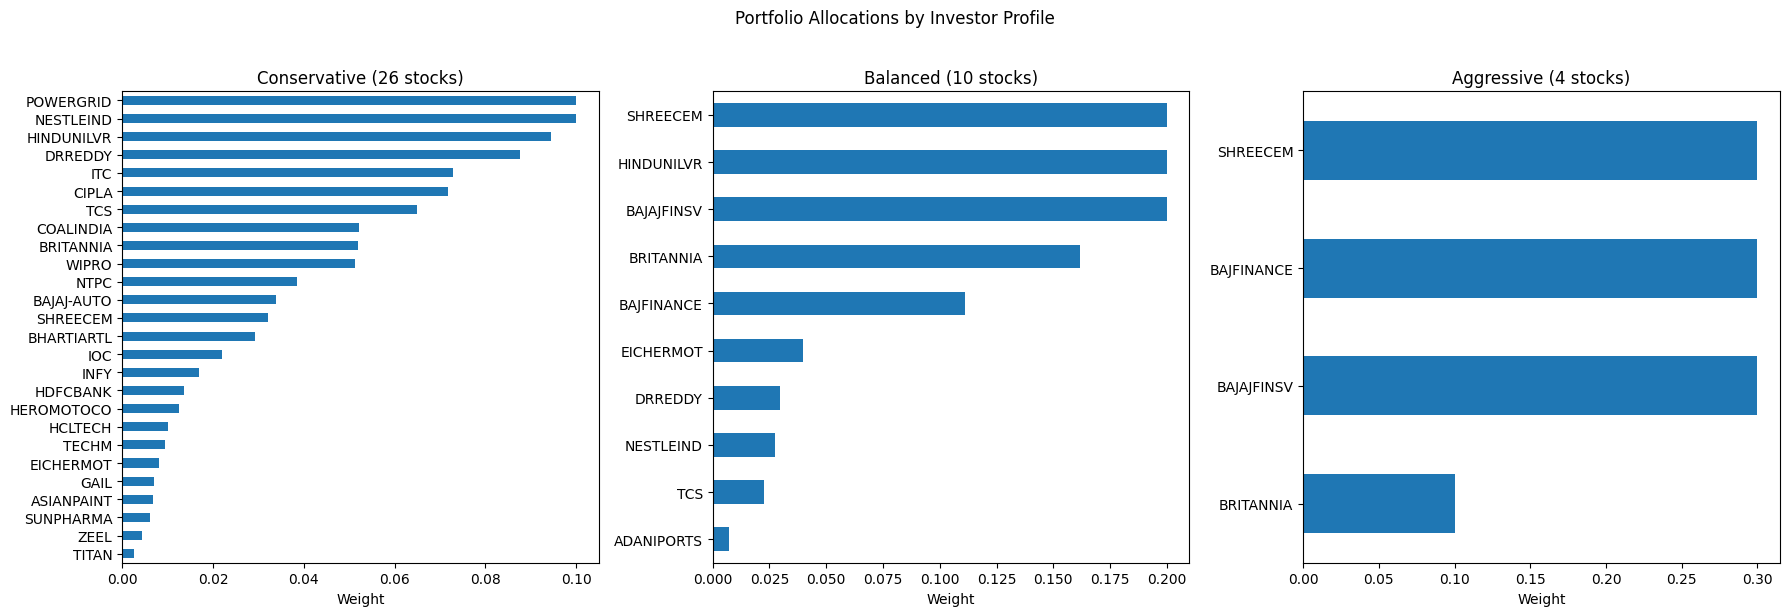

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, w) in zip(axes, [('Conservative', w_con), ('Balanced', w_bal), ('Aggressive', w_agg)]):
    weights = pd.Series(w, index=returns.columns)
    top = weights[weights > 0.001].sort_values(ascending=True)
    top.plot.barh(ax=ax)
    ax.set_title(f'{name} ({len(top)} stocks)')
    ax.set_xlabel('Weight')

plt.suptitle('Portfolio Allocations by Investor Profile', y=1.02)
plt.tight_layout()
plt.show()

## 4.5 Efficient Frontier

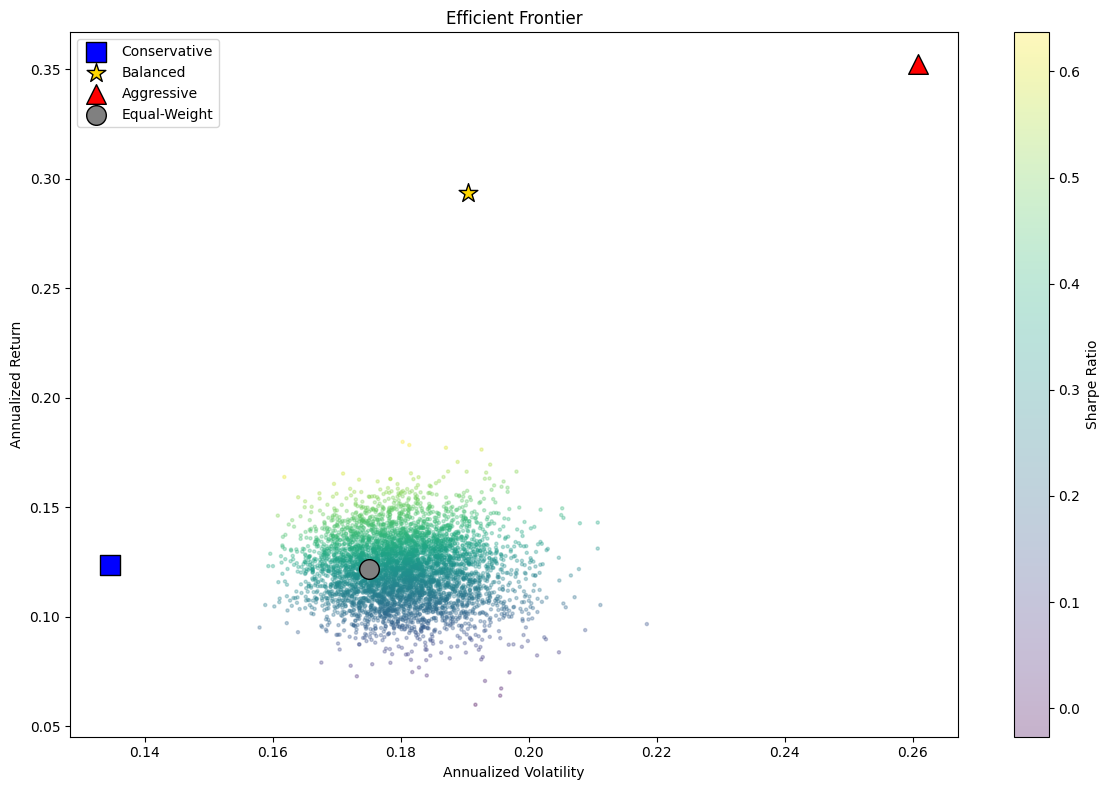

In [6]:
# Generate random portfolios for the frontier
np.random.seed(42)
n_sim = 5000
sim_ret, sim_vol, sim_sharpe = [], [], []

for _ in range(n_sim):
    w = np.random.dirichlet(np.ones(n))
    r, v, s = portfolio_stats(w)
    sim_ret.append(r)
    sim_vol.append(v)
    sim_sharpe.append(s)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(sim_vol, sim_ret, c=sim_sharpe, cmap='viridis', alpha=0.3, s=5)
plt.colorbar(scatter, label='Sharpe Ratio')

# Plot optimized portfolios
for name, w, marker, color in [
    ('Conservative', w_con, 's', 'blue'),
    ('Balanced', w_bal, '*', 'gold'),
    ('Aggressive', w_agg, '^', 'red'),
    ('Equal-Weight', w_eq, 'o', 'gray'),
]:
    r, v, _ = portfolio_stats(w)
    ax.scatter(v, r, marker=marker, s=200, color=color, edgecolors='black', label=name, zorder=5)

ax.set_xlabel('Annualized Volatility')
ax.set_ylabel('Annualized Return')
ax.set_title('Efficient Frontier')
ax.legend()
plt.tight_layout()
plt.show()

## 4.6 Sector Breakdown of Each Portfolio

In [7]:
for name, w in [('Conservative', w_con), ('Balanced', w_bal), ('Aggressive', w_agg)]:
    weights = pd.Series(w, index=returns.columns)
    weights = weights[weights > 0.001]

    # Map stock to sector
    sector_weights = {}
    for sym, wt in weights.items():
        sector = meta.loc[sym, 'Industry'] if sym in meta.index else 'Unknown'
        sector_weights[sector] = sector_weights.get(sector, 0) + wt

    print(f'\n{name} — Sector Allocation:')
    for sector, wt in sorted(sector_weights.items(), key=lambda x: -x[1]):
        print(f'  {sector}: {wt*100:.1f}%')


Conservative — Sector Allocation:
  CONSUMER GOODS: 32.9%
  ENERGY: 16.7%
  PHARMA: 16.5%
  IT: 15.3%
  AUTOMOBILE: 5.4%
  METALS: 5.2%
  CEMENT & CEMENT PRODUCTS: 3.2%
  TELECOM: 2.9%
  FINANCIAL SERVICES: 1.4%
  MEDIA & ENTERTAINMENT: 0.4%

Balanced — Sector Allocation:
  CONSUMER GOODS: 38.9%
  FINANCIAL SERVICES: 31.1%
  CEMENT & CEMENT PRODUCTS: 20.0%
  AUTOMOBILE: 4.0%
  PHARMA: 3.0%
  IT: 2.3%
  SERVICES: 0.7%

Aggressive — Sector Allocation:
  FINANCIAL SERVICES: 60.0%
  CEMENT & CEMENT PRODUCTS: 30.0%
  CONSUMER GOODS: 10.0%


## 4.7 Key Findings

- **Conservative portfolio** spreads weight across many stocks (max 10% each) → lowest volatility
- **Balanced portfolio** concentrates on highest Sharpe-ratio stocks (max 20% each)
- **Aggressive portfolio** concentrates on top-returning stocks (max 30% each) → highest risk
- All optimized portfolios sit on or near the efficient frontier
- Equal-weight baseline is a reasonable middle ground